In [ ]:
# ============================================
# CELL 1 — INSTALL LIBRARIES
# ============================================

!pip install xgboost opencv-python kagglehub -q

In [ ]:
# ============================================
# CELL 2 — IMPORT LIBRARIES
# ============================================

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [ ]:
# ============================================
# CELL 3 — DOWNLOAD DATASET
# ============================================

path = kagglehub.dataset_download(
    "sartajbhuvaji/brain-tumor-classification-mri"
)

print("Dataset Path:", path)

100%|██████████| 86.8M/86.8M [00:00<00:00, 150MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3


In [ ]:
# ============================================
# CELL 4 — DEFINE CLASSES
# ============================================

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

In [ ]:
# ============================================
# CELL 5 — LOAD DATASET
# ============================================

IMG_SIZE = 200

train_path = os.path.join(path, "Training")

X = []
Y = []

for cls, label in classes.items():

    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None:

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            img = img.flatten() / 255.0

            X.append(img)

            Y.append(label)

X = np.array(X)

Y = np.array(Y)

print("Dataset Loaded Successfully")

print("X Shape :", X.shape)

print("Y Shape :", Y.shape)

Dataset Loaded Successfully
X Shape : (2870, 40000)
Y Shape : (2870,)


In [ ]:
# ============================================
# CELL 6 — DATA SPLITS
# ============================================

splits = [
    (0.2, 0.8),
    (0.4, 0.6),
    (0.6, 0.4),
    (0.8, 0.2)
]


TRAIN : 20%
TEST  : 80%
Training Samples : 574
Testing Samples  : 2296
PCA Components Retained : 323

Training XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.6986062717770035
F1 Score          : 0.6847219222692253

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.78      0.40      0.53       316
 Pituitary Tumor       0.79      0.93      0.85       662
    Glioma Tumor       0.63      0.79      0.70       661
Meningioma Tumor       0.64      0.51      0.57       657

        accuracy                           0.70      2296
       macro avg       0.71      0.66      0.66      2296
    weighted avg       0.70      0.70      0.68      2296



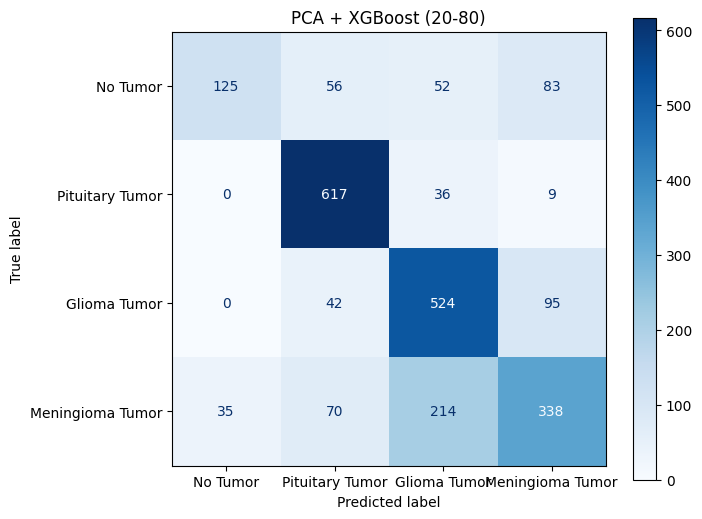


TRAIN : 40%
TEST  : 60%
Training Samples : 1148
Testing Samples  : 1722
PCA Components Retained : 537

Training XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.7392566782810686
F1 Score          : 0.7296583570205375

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.85      0.42      0.56       237
 Pituitary Tumor       0.81      0.93      0.87       496
    Glioma Tumor       0.71      0.80      0.75       496
Meningioma Tumor       0.66      0.64      0.65       493

        accuracy                           0.74      1722
       macro avg       0.76      0.70      0.71      1722
    weighted avg       0.74      0.74      0.73      1722



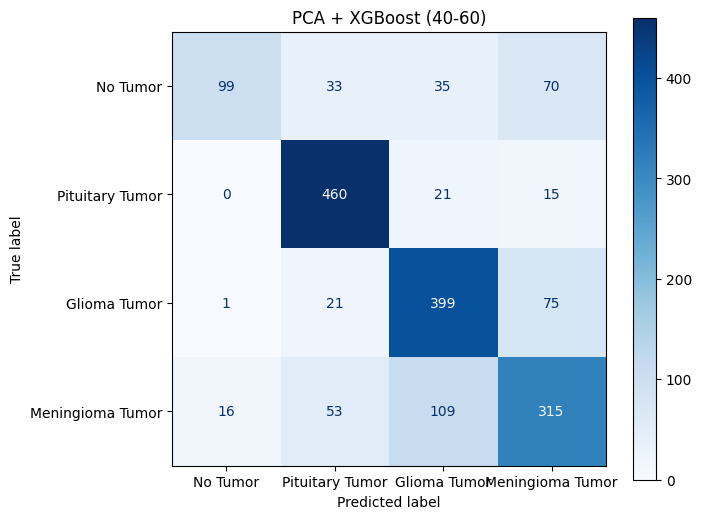


TRAIN : 60%
TEST  : 40%
Training Samples : 1722
Testing Samples  : 1148
PCA Components Retained : 688

Training XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.7630662020905923
F1 Score          : 0.7557055412795327

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.82      0.46      0.59       158
 Pituitary Tumor       0.83      0.95      0.89       331
    Glioma Tumor       0.77      0.79      0.78       330
Meningioma Tumor       0.67      0.69      0.68       329

        accuracy                           0.76      1148
       macro avg       0.77      0.72      0.73      1148
    weighted avg       0.76      0.76      0.76      1148



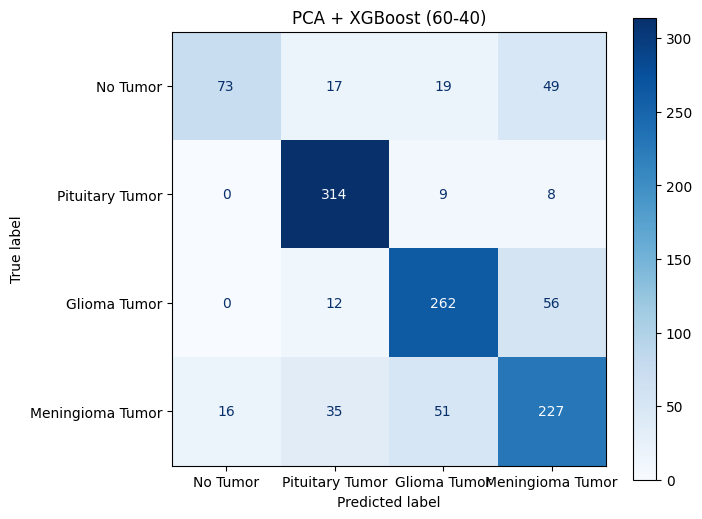


TRAIN : 80%
TEST  : 20%
Training Samples : 2296
Testing Samples  : 574
PCA Components Retained : 808

Training XGBoost Model...
Training Completed
Training Accuracy : 1.0
Testing Accuracy  : 0.7909407665505227
F1 Score          : 0.7877617660122996

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.81      0.66      0.73        79
 Pituitary Tumor       0.84      0.95      0.89       166
    Glioma Tumor       0.80      0.81      0.80       165
Meningioma Tumor       0.71      0.68      0.70       164

        accuracy                           0.79       574
       macro avg       0.79      0.77      0.78       574
    weighted avg       0.79      0.79      0.79       574



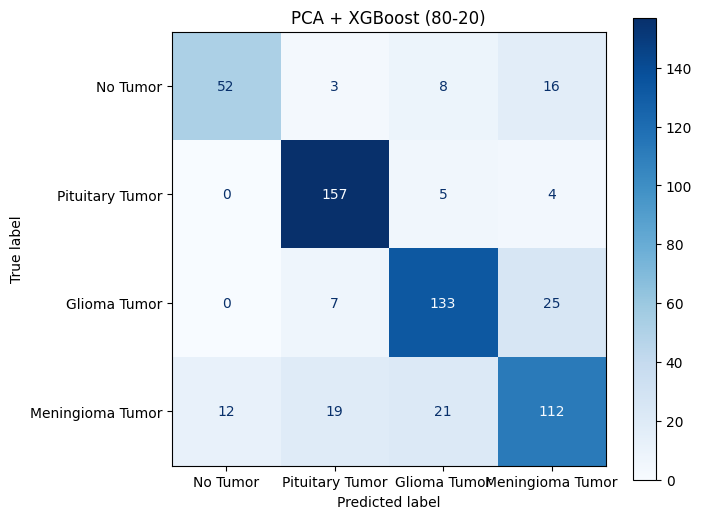

In [ ]:
# ============================================
# CELL 7 — PCA + XGBOOST TRAINING
# ============================================

train_acc_list = []

test_acc_list = []

f1_list = []

labels = []

for train_ratio, test_ratio in splits:

    print("\n====================================")

    print(f"TRAIN : {int(train_ratio*100)}%")

    print(f"TEST  : {int(test_ratio*100)}%")

    print("====================================")

    # TRAIN TEST SPLIT
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_ratio,
        test_size=test_ratio,
        random_state=42,
        stratify=Y
    )

    print("Training Samples :", xtrain.shape[0])

    print("Testing Samples  :", xtest.shape[0])

    # PCA
    pca = PCA(
        n_components=0.95,
        random_state=42
    )

    pca_train = pca.fit_transform(xtrain)

    pca_test = pca.transform(xtest)

    print("PCA Components Retained :", pca.n_components_)

    # XGBOOST MODEL
    xgb = XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining XGBoost Model...")

    xgb.fit(
        pca_train,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(pca_train)

    test_pred = xgb.predict(pca_test)

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        ytest,
        test_pred
    )

    f1 = f1_score(
        ytest,
        test_pred,
        average='weighted'
    )

    print("Training Accuracy :", train_acc)

    print("Testing Accuracy  :", test_acc)

    print("F1 Score          :", f1)

    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    labels.append(
        f"{int(train_ratio*100)}-{int(test_ratio*100)}"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            ytest,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(
        ytest,
        test_pred
    )

    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True
    )

    plt.title(
        f"PCA + XGBoost ({int(train_ratio*100)}-{int(test_ratio*100)})"
    )

    plt.show()

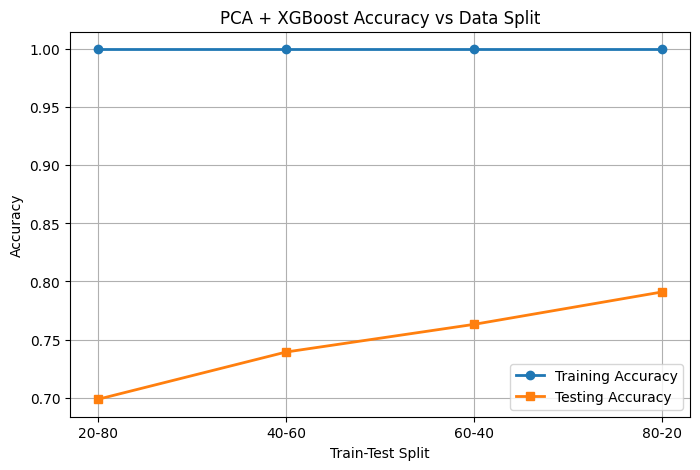

In [ ]:
# ============================================
# CELL 8 — ACCURACY PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Accuracy")

plt.title("PCA + XGBoost Accuracy vs Data Split")

plt.legend()

plt.grid(True)

plt.show()

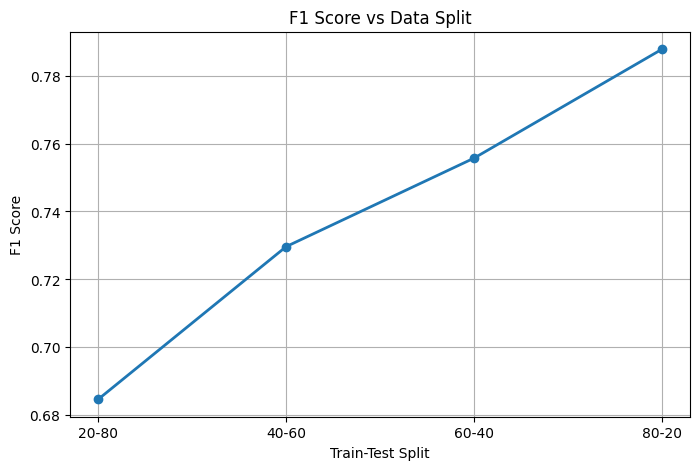

In [ ]:
# ============================================
# CELL 9 — F1 SCORE PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("F1 Score vs Data Split")

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# CELL 10 — RESULTS TABLE
# ============================================

results_df = pd.DataFrame({
    'Train-Test Split': labels,
    'Training Accuracy': train_acc_list,
    'Testing Accuracy': test_acc_list,
    'F1 Score': f1_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score
0            20-80                1.0          0.698606  0.684722
1            40-60                1.0          0.739257  0.729658
2            60-40                1.0          0.763066  0.755706
3            80-20                1.0          0.790941  0.787762


In [ ]:
# ============================================
# CELL 11 — SAMPLE PREDICTIONS
# ============================================

def display_samples(folder, title, num_samples=9):

    valid_ext = ('.jpg', '.jpeg', '.png')

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    plt.figure(figsize=(12,8))

    for i, filename in enumerate(imgs):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        img_flat = img.flatten()/255.0

        pred = xgb.predict(
            pca.transform([img_flat])
        )[0]

        plt.subplot(3,3,i+1)

        plt.imshow(
            img,
            cmap='gray'
        )

        plt.title(dec[pred])

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

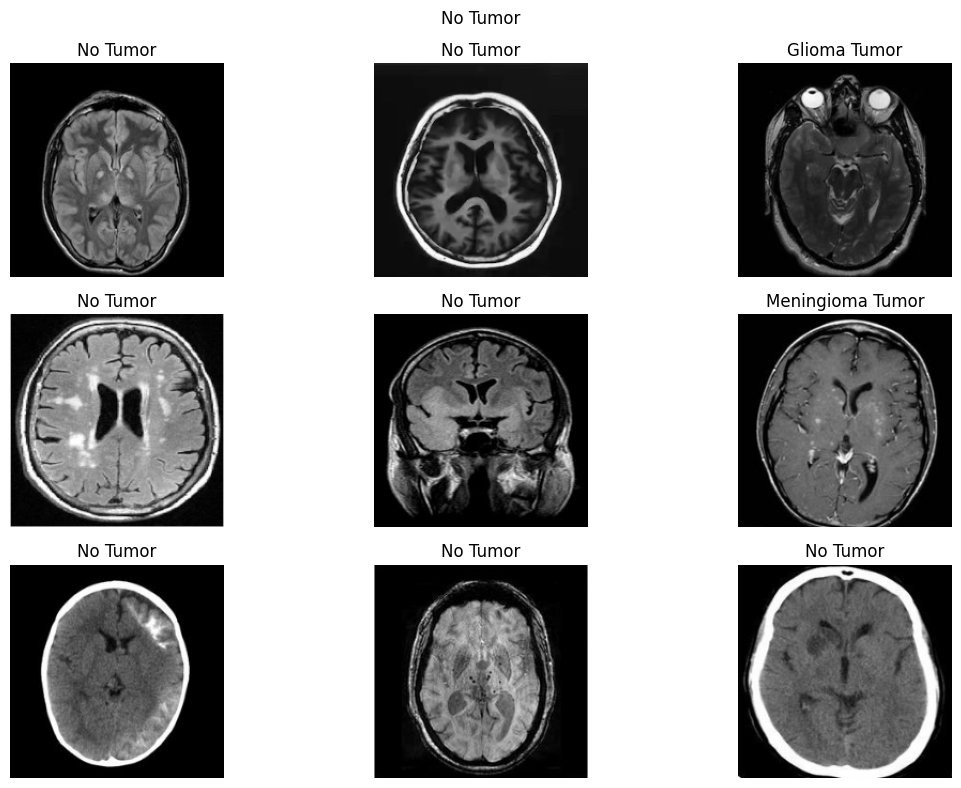

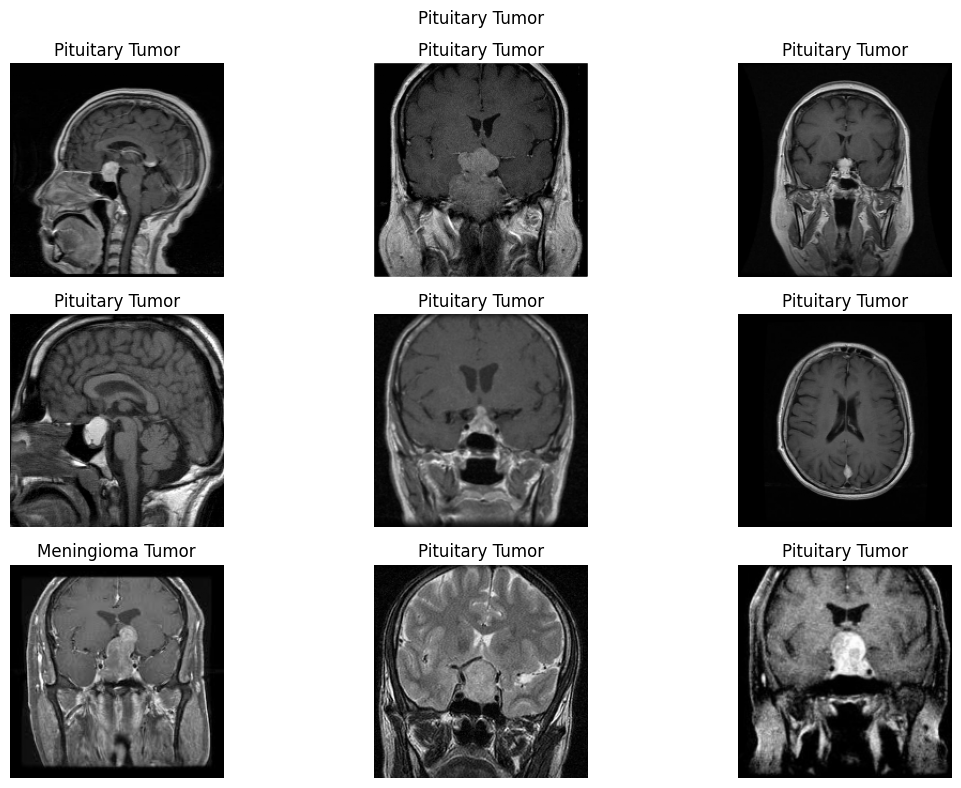

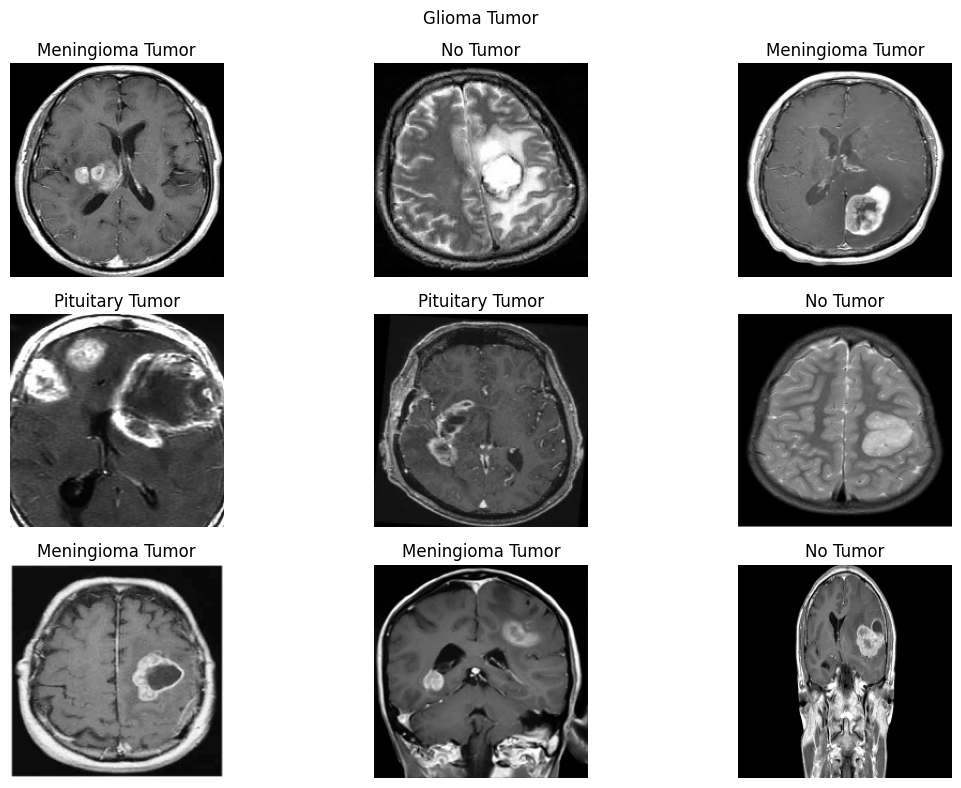

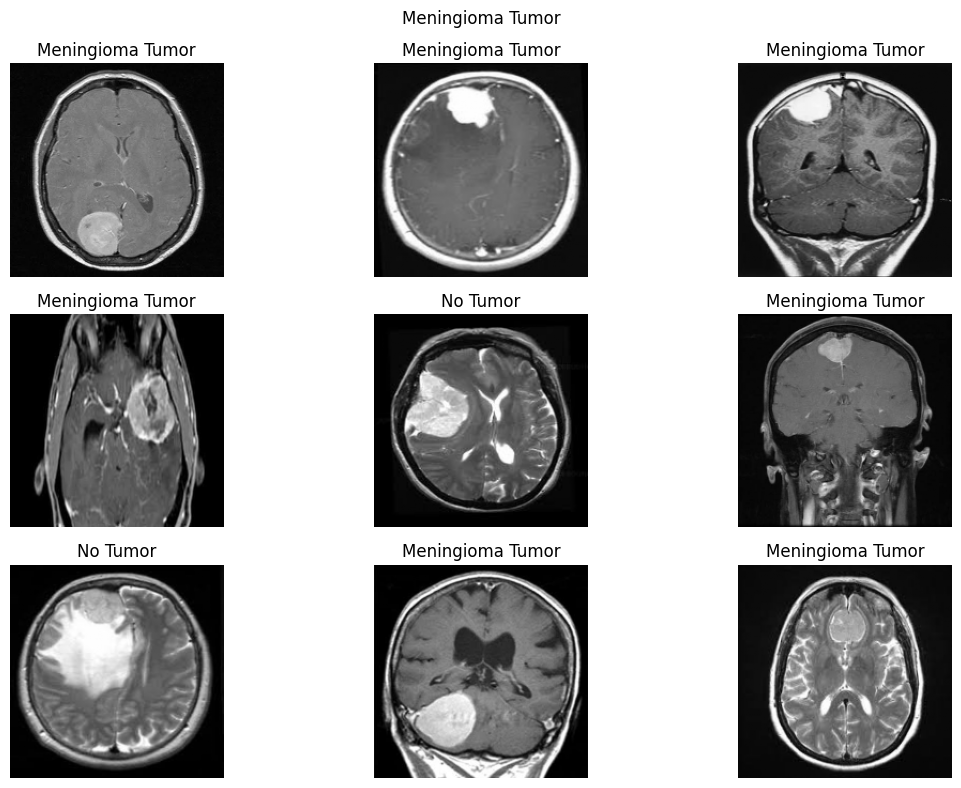

In [ ]:
# ============================================
# CELL 12 — DISPLAY SAMPLE PREDICTIONS
# ============================================

test_path = os.path.join(path, "Testing")

for tumor_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        tumor_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            tumor_folder.replace("_"," ").title()
        )

In [ ]:
# ============================================
# CELL 13 — DATASET DISTRIBUTION
# ============================================

tumor_counts = {
    dec[label]: int(np.sum(Y == label))
    for label in classes.values()
}

df = pd.DataFrame({
    'Tumor Type': list(tumor_counts.keys()),
    'Count': list(tumor_counts.values())
})

print(df)

         Tumor Type  Count
0          No Tumor    395
1   Pituitary Tumor    827
2      Glioma Tumor    826
3  Meningioma Tumor    822


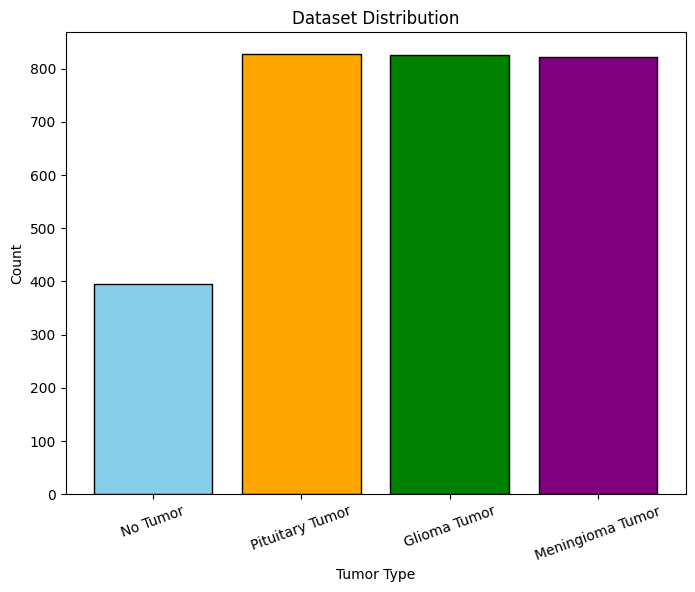

In [ ]:
# ============================================
# CELL 14 — DISTRIBUTION PLOT
# ============================================

colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8,6))

for label, color in zip(classes.values(), colors):

    plt.bar(
        dec[label],
        int(np.sum(Y == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Tumor Type")

plt.ylabel("Count")

plt.title("Dataset Distribution")

plt.xticks(rotation=20)

plt.show()

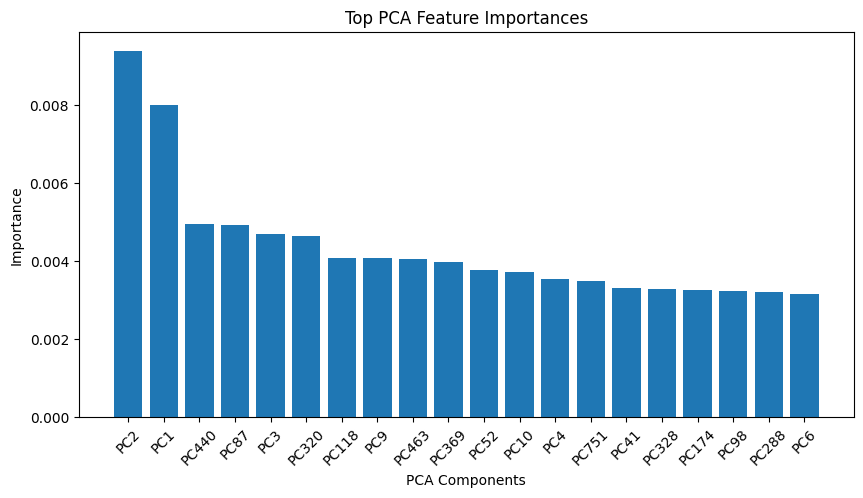

In [ ]:
# ============================================
# CELL 15 — FEATURE IMPORTANCE
# ============================================

importances = xgb.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"PC{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("PCA Components")

plt.ylabel("Importance")

plt.title("Top PCA Feature Importances")

plt.show()